# Evaluate Forward Model.

## Import the libaries.

In [1]:
import sys

import hydra
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
from scipy.special import softmax
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from tqdm import tqdm
import torch

from sc_exp_design.constants import PredictionFields


## Import additional modules.

In [2]:
sys.path.insert(0, "/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/collab-goettgens-SFC/shared_utils")

from data_utils import get_protocol_tranformations
from experiment_utils import get_transformed_data, get_forward_model

## Define paths.

In [3]:
perturbation_prediction_path = "/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/output/checkpoints/conditional_model/flow_matching/2026-04-02_14-16-39/crisp-pine-1_FlowMatching.pkl"
unique_conc_data_path = "/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/output/miscellaneous/unique_concentrations_adata_bloodplus.h5ad"
classifier_path = "/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/output/checkpoints/cell_type_classifier/2026-04-08_00-00-38/easy-monkey-341_TargetPredictionModel.pkl"

## Define utility functions.

In [4]:
def query_forwad_model(
    cond,
    forward_model,
    n_samples,
    num_time_steps,
    solver_kwargs,
    le_ct,
    n_scatter_feats=6,
):
    cond = torch.from_numpy(cond).\
        unsqueeze(0).repeat(n_samples, 1).\
        float().to(forward_model.forward_model.device)
    batch_dict = {
        "condition": {"feats_condition_concat_condition_concat": cond}
    }   # query forward model
    cforward_out = forward_model.predict(
        batch_dict,
        return_trajectory=False,
        no_grad=True,
        num_time_steps=num_time_steps,
        solver_kwargs=solver_kwargs,
        fix_noise=False,
    )
    X_gen = cforward_out[PredictionFields.PREDICTION_DATA].detach().cpu().numpy()
    gen_ct_logits = cforward_out[PredictionFields.TARGET_PREDICTION_DATA]["cell_type"].detach().cpu().numpy()

    # split channel and scatter features
    X_channel_gen = X_gen[..., :-n_scatter_feats]
    X_scatter_gen = X_gen[..., -n_scatter_feats:]

    # compute cell type probabilities and labels
    gen_ct_probs = softmax(gen_ct_logits, axis=-1)
    gen_ct_id_label = gen_ct_probs.argmax(-1)
    gen_ct_label = le_ct.inverse_transform(gen_ct_id_label.reshape(-1)).\
        reshape(gen_ct_id_label.shape[0],)
        # reshape(gen_ct_id_label.shape[0], gen_ct_probs.shape[1])
    return {
        "X": X_gen,
        "X_channel": X_channel_gen,
        "X_scatter": X_scatter_gen,
        "ct_logits": gen_ct_logits,
        "ct_probs": gen_ct_probs,
        "ct_label": gen_ct_label,
    }

def get_adata(
    pred,
    adata,
    X_conc,
    idx,
    scatter_columns,
    protocol_columns,
    column2tranform,
    compute_stuff=False
):
    X_true = adata.obsm['X_channel_standardized+X_scatter']
    n_samples = pred.shape[0]
    X = np.concat((X_true, pred))
    X_channel = X[..., :20]
    X_scatter = X[..., 20:]
    # obsm
    obsm = {
        "X_channel_standardized": X_channel,
        "X_scatter_standardized": X_scatter,
        "X_channel_standardized+X_scatter_standardized": X,
        "condition_concat": np.concatenate(
            (
                adata.obsm["condition_concat"],
                np.repeat(X_conc[idx][None], n_samples, axis=0),
            ), axis=0
        )
    }
    # obs
    data_dict_transformed, data_dict_original = get_transformed_data(
        obsm["condition_concat"],
        protocol_columns,
        column2tranform,
    )
    obs = pd.DataFrame(
        {
            "dataset_type": ["real"]*len(adata) + ["gen"]*n_samples,
            **{
                col: X_scatter[:, idx] for idx, col in enumerate(scatter_columns)
            },
            **{

            }, 
            **data_dict_original,
            **{f"{k}:transformed": v for k, v in data_dict_transformed.items()}
        }
    )
    adata_gen = sc.AnnData(
        X=X_channel,
        obs=obs,
        var=adata.var,
        obsm=obsm,
        uns=adata.uns
    )
    if compute_stuff:
        sc.pp.pca(adata_gen)
        sc.pp.neighbors(adata_gen)
        sc.tl.umap(adata_gen)
    return adata_gen


def scatterplot(ct_adata, cond=None, target_ct=None, base="X_umap"):
    X_umap = ct_adata.obsm[base]
    if cond is not None:
        cond_mask = np.all(ct_adata.obsm["condition_concat"] == cond, axis=-1)
        ct_mask = cond_mask & (ct_adata.obs["dataset_type"] != "gen")
    else:
        ct_mask = (ct_adata.obs["dataset_type"] != "gen")

    gen_mask = ct_adata.obs["dataset_type"] == "gen"
    fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharex=True, sharey=True)
    fig.suptitle(target_ct)
    axes[0].scatter(
        X_umap[:, 0],
        X_umap[:, 1],
        s=5,
    )
    axes[0].scatter(
        X_umap[ct_mask, 0],
        X_umap[ct_mask, 1],
        s=40,
    )
    axes[0].set_title(f"Is Target")
    axes[0].grid(1)

    axes[1].scatter(
        X_umap[:, 0],
        X_umap[:, 1],
        s=5,
    )
    axes[1].scatter(
        X_umap[gen_mask, 0],
        X_umap[gen_mask, 1],
        s=40,
    )
    axes[1].set_title("Is Generated")
    axes[1].grid(1)

    for ax in axes:
        ax.set_xlabel("UMAP1")
        ax.set_ylabel("UMAP2")

    plt.tight_layout()
    return fig


def dotplot(adata, cond=None, vmin=0.0, vmax=30.0):
    
    gen_mask = adata.obs["dataset_type"]=="gen"
    if cond is not None:
        cond_mask = np.all(adata.obsm["condition_concat"] == cond, axis=-1)
        target_mask = ~gen_mask & cond_mask
    else:
        target_mask = ~gen_mask

    adata_gen = adata[gen_mask]
    adata_real = adata[target_mask]

    fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharey=True)
    sc.pl.dotplot(
        adata_gen,
        adata.var_names,
        groupby="dataset_type",
        ax=axes[0],
        show=False, vmin=vmin, vmax=vmax
    )
    axes[0].set_title(f"Generated")

    sc.pl.dotplot(
        adata_real,
        adata_real.var_names,
        groupby="dataset_type",
        ax=axes[1],
        show=False, vmin=vmin, vmax=vmax
    )
    axes[0].set_title(f"Target")
    fig.tight_layout()
    return fig

## Read configurations.

In [5]:
with hydra.initialize(version_base=None, config_path="../../../../../inverse/loss_guidance/config"):
    config = hydra.compose(
        config_name="run_inverse",
        overrides=[
            f"paths.perturbation_prediction_path={perturbation_prediction_path}",
            f"paths.ct_classifier_path={classifier_path}"
        ]
    )
scatter_columns = config.annotation["scatter_columns"]
protocol_columns = config.annotation["protocol_columns"]
log1p_exp_cols = config.annotation["log1p_exp_cols"]
log21p_exp_cols = config.annotation["log21p_exp_cols"]


## Prepare Transformations.

In [6]:
column2tranform = get_protocol_tranformations(
    protocol_columns,
    log1p_exp_cols=log1p_exp_cols,
    log21p_exp_cols=log21p_exp_cols,
    inverse=True,
)
column2tranform

{'gm-csf_[ng_ml]': <ufunc 'expm1'>,
 'tpo_[ng_ml]': <ufunc 'expm1'>,
 'sr1_[nm]': <ufunc 'expm1'>,
 'um171_[nm]': <ufunc 'expm1'>,
 'um729_[µm]': <ufunc 'expm1'>,
 'scf_[ng_ml]': <ufunc 'expm1'>,
 'butyzamide_[nm]': <ufunc 'expm1'>,
 'retinoic_acid_[µm]': <ufunc 'expm1'>,
 'ldl_[ng_ml]': <ufunc 'expm1'>,
 'il3_[ng_ml]': <ufunc 'expm1'>,
 'o2_[%]': <ufunc 'expm1'>,
 'days_of_culture': <ufunc 'expm1'>}

## Read unique concentrations data.

In [7]:
# adata = sc.read_h5ad("/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/data/gdrive/new_dataset/BloodPlus_celltype_pm_500k_.h5ad")
# protocol_values = adata.obs.loc[:, list(column2tranform.keys())].values.astype(float)
# protocol_values_unique = np.log1p(np.unique(protocol_values, axis=0))

In [8]:
# np.unique(protocol_values_unique, axis=0).shape

In [9]:
unique_conc_data = sc.read_h5ad(unique_conc_data_path)
X_conc = unique_conc_data.X
X_conc.shape

(103, 12)

In [10]:
# Verify if protocols correspond between the two 

# np.all(protocol_values_unique[:, None, :] == X_conc[None, :, :], axis=2).any(1).sum()

In [11]:
# var = pd.DataFrame(index=list(column2tranform.keys()))
# unique_conc_data_new = sc.AnnData(X=protocol_values_unique, 
#                                  var=var)

In [12]:
# unique_conc_data_new.write_h5ad("/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/output/miscellaneous/unique_concentrations_adata_bloodplus.h5ad")

In [13]:
# del adata

## Load forward model.

In [14]:
forward_model, (
    flow_matching,
    ct_classifier 
) = get_forward_model(config)
flow_matching.velocity_field.eval()
print(flow_matching.velocity_field)

NeuralVelocityField(
  (vf_modules): ModuleDict(
    (x_encoder): MLPBlock(
      (net): Sequential(
        (0): Sequential(
          (0): Linear(in_features=26, out_features=1024, bias=True)
          (1): ELU(alpha=1.0)
        )
        (1): Sequential(
          (0): Linear(in_features=1024, out_features=1024, bias=True)
          (1): ELU(alpha=1.0)
        )
        (2): Sequential(
          (0): Linear(in_features=1024, out_features=256, bias=True)
          (1): Identity()
        )
      )
    )
    (time_encoder): MLPBlock(
      (net): Sequential(
        (0): Sequential(
          (0): Linear(in_features=512, out_features=1024, bias=True)
          (1): ELU(alpha=1.0)
        )
        (1): Sequential(
          (0): Linear(in_features=1024, out_features=1024, bias=True)
          (1): ELU(alpha=1.0)
        )
        (2): Sequential(
          (0): Linear(in_features=1024, out_features=128, bias=True)
          (1): Identity()
        )
      )
    )
    (condition_enco

In [15]:
# np.unique(flow_matching.train_data.perturbation_data["feats_condition_concat_condition_concat"], axis=0)
train_shape = flow_matching.train_data.perturbation_data["feats_condition_concat_condition_concat"].shape
train_shape

(36460035, 12)

In [16]:
subset_indices = np.random.randint(0, train_shape[0], 500000)
np.unique(
    flow_matching.train_data.perturbation_data["feats_condition_concat_condition_concat"][subset_indices], axis=0
).shape

(103, 12)

In [17]:
ct_classifier.train_data.state_data.shape

(330285, 26)

Fwd model was trained on the right data 

## Prepare label encoder.

In [18]:
ct_le = LabelEncoder()
ct_values = ct_classifier.train_data.adata.obs["cell_type"].values
ct_le.fit(ct_values)
classes = ct_le.classes_.tolist()

## Subsample state data.

In [19]:
adata = flow_matching.train_data.adata
adata = sc.pp.sample(adata, n=75_000, copy=True)
adata

AnnData object with n_obs × n_vars = 75000 × 20
    obs: 'experiment_number', 'replicate', 'date', 'cytometer', 'cytometer_serial_no', 'well_id', 'count_beads', 'cell_counts', 'experiment_id', '740-yp_[µm]', 'mtg_[µm]', 'rhflt3l_[ng_ml]', 'gm-csf_[ng_ml]', 'tpo_[ng_ml]', 'sr1_[nm]', 'um171_[nm]', 'um729_[µm]', 'scf_[ng_ml]', 'butyzamide_[nm]', 'retinoic_acid_[µm]', 'ldl_[ng_ml]', 'il3_[ng_ml]', 'source_id', 'hydrogel_type', 'o2_[%]', 'source_cell_phenotype', 'total_count_beads', 'counts_source_cell_phenotype', 'days_of_culture', 'plate', 'absolute_number_multiplier_[2^n]', 'cytometer_id', 'FSC-A :: FSC - Area', 'FSC-H :: FSC - Height', 'FSC-W :: FSC - Width', 'SSC-A :: SSC - Area', 'SSC-H :: SSC - Height', 'SSC-W :: SSC - Width', 'TIME', 'NA', 'AF Index', 'batch', '7-AAD'
    var: 'n', 'channel', 'marker', 'PnB', 'PnE', 'PnR', 'PnD', 'signal_type', 'antibody'
    uns: 'meta', 'processing_steps', 'pca', 'X_scatter_params', 'X_channel_params', 'X_channel+X_scatter_zca_whitened', 'X_chann

## Sample from each conditional distribution.

In [20]:
num_time_steps = 50
solver_kwargs = {"method": "euler"}
n_samples = 750
pred_dict = {}

for idx, cond in tqdm(enumerate(X_conc)):
    pred_dict[idx] = query_forwad_model(
        cond,
        forward_model,
        n_samples,
        num_time_steps,
        solver_kwargs,
        ct_le,
        n_scatter_feats=len(scatter_columns),
    )

103it [00:16,  6.25it/s]


## Annotate the predictions for visualization.

In [21]:
compute_stuff = True
adatas_dict = {}
for idx, pred in tqdm(pred_dict.items()):
    if idx >= 3: break
    adatas_dict[idx] = get_adata(
        pred["X"],
        adata,
        X_conc,
        idx,
        scatter_columns,
        protocol_columns,
        column2tranform,
        compute_stuff=compute_stuff
    )

  0%|          | 0/103 [00:00<?, ?it/s]/home/icb/alessandro.palma/miniconda3/envs/sc_exp_design_12/lib/python3.12/functools.py:912: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
  1%|          | 1/103 [01:39<2:49:23, 99.64s/it]/home/icb/alessandro.palma/miniconda3/envs/sc_exp_design_12/lib/python3.12/functools.py:912: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
  2%|▏         | 2/103 [02:17<1:46:42, 63.39s/it]/home/icb/alessandro.palma/miniconda3/envs/sc_exp_design_12/lib/python3.12/functools.py:912: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
  3%|▎         | 3/103 [02:57<1:38:41, 59.21s/it]


## Visualize Umaps.

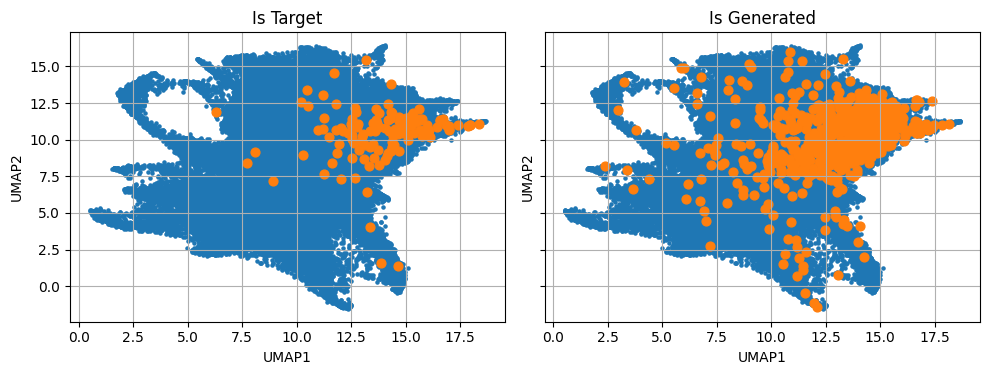

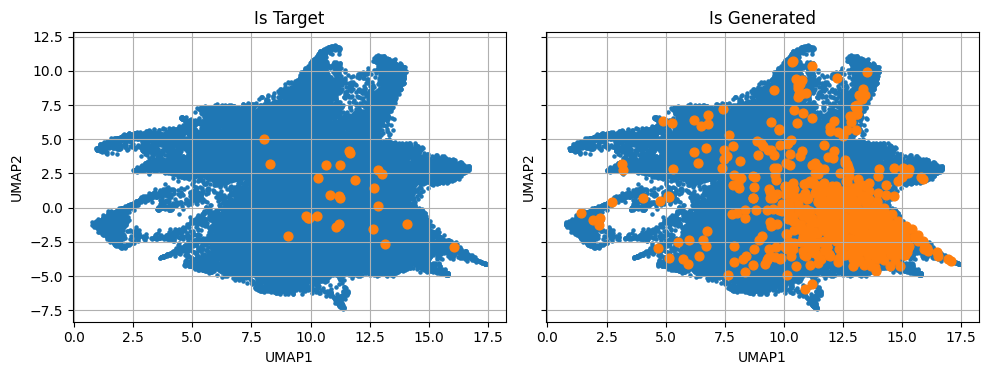

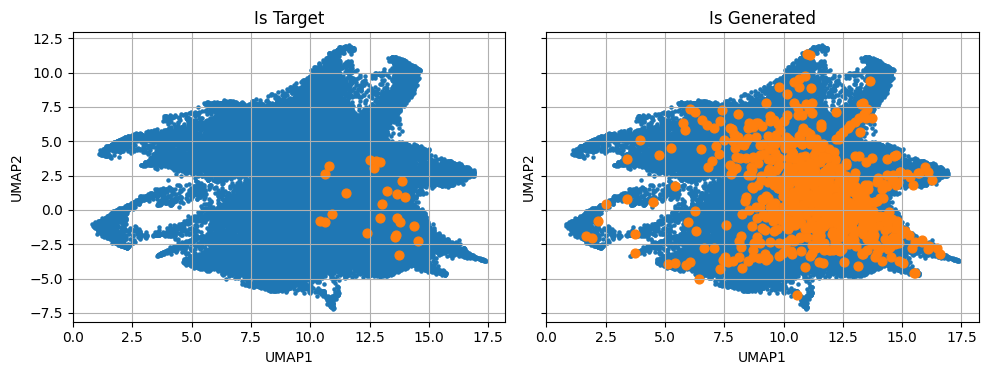

In [22]:
if compute_stuff:
    for idx, adata_cond in adatas_dict.items():
        scatterplot(adata_cond, X_conc[idx])

## Dotplot.

/home/icb/alessandro.palma/miniconda3/envs/sc_exp_design_12/lib/python3.12/site-packages/anndata/_core/anndata.py:1208: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/home/icb/alessandro.palma/miniconda3/envs/sc_exp_design_12/lib/python3.12/site-packages/anndata/_core/anndata.py:1208: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/home/icb/alessandro.palma/miniconda3/envs/sc_exp_design_12/lib/python3.12/site-packages/anndata/_core/anndata.py:1208: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/home/icb/alessandro.palma/miniconda3/envs/sc_exp_design_12/lib/python3.12/site-packages/anndata/_core/anndata.py:1208: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/home/icb/alessandro.palma/miniconda3/envs/sc_exp_design_12/

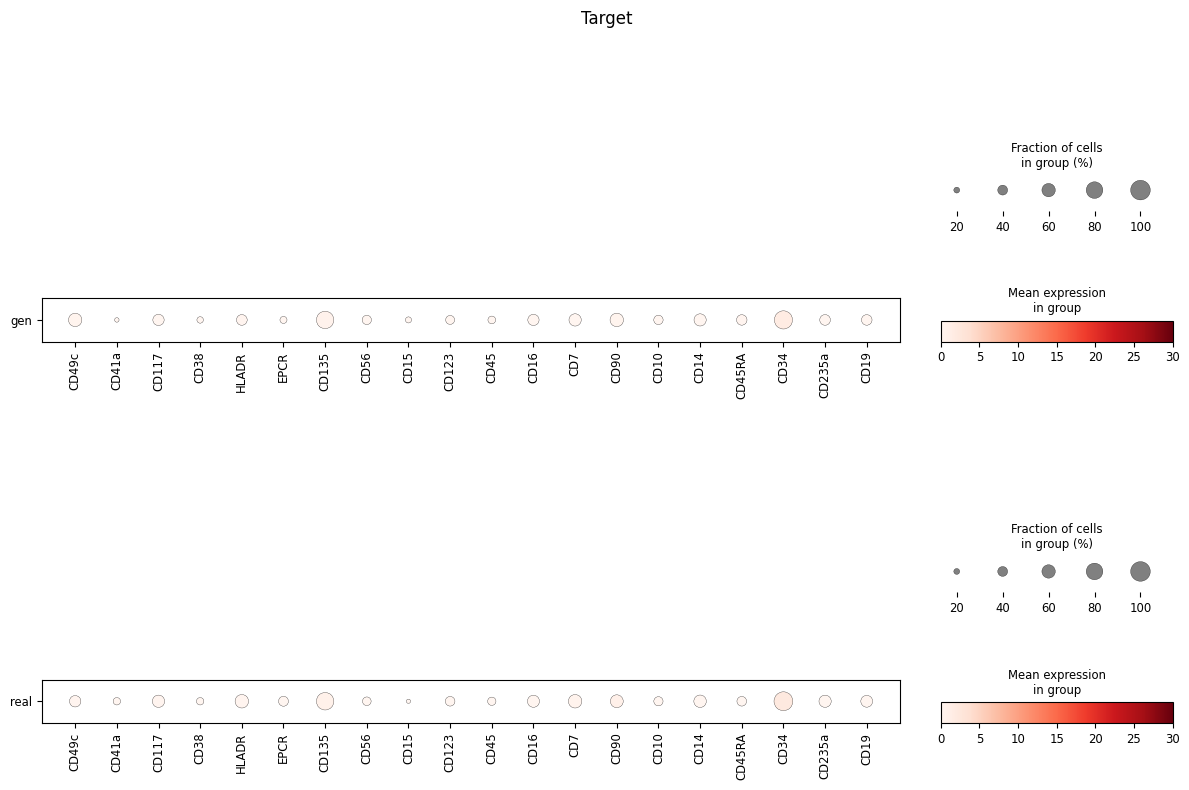

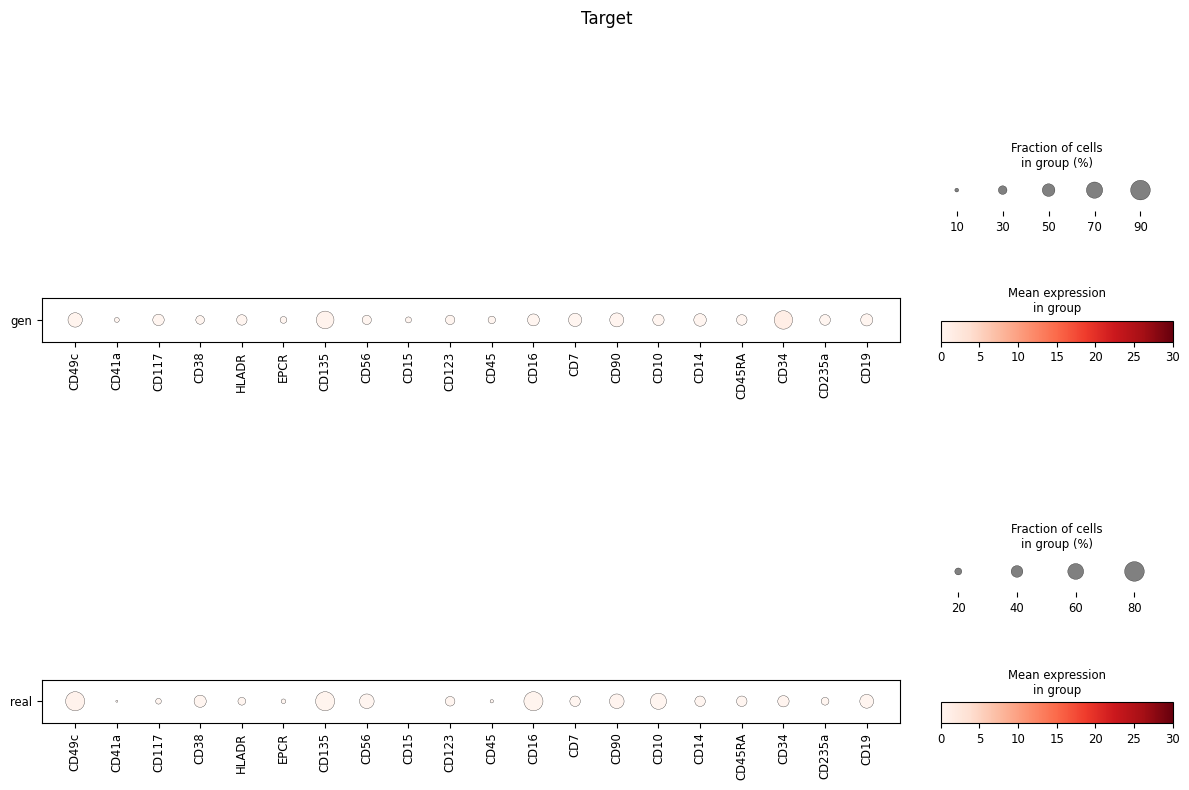

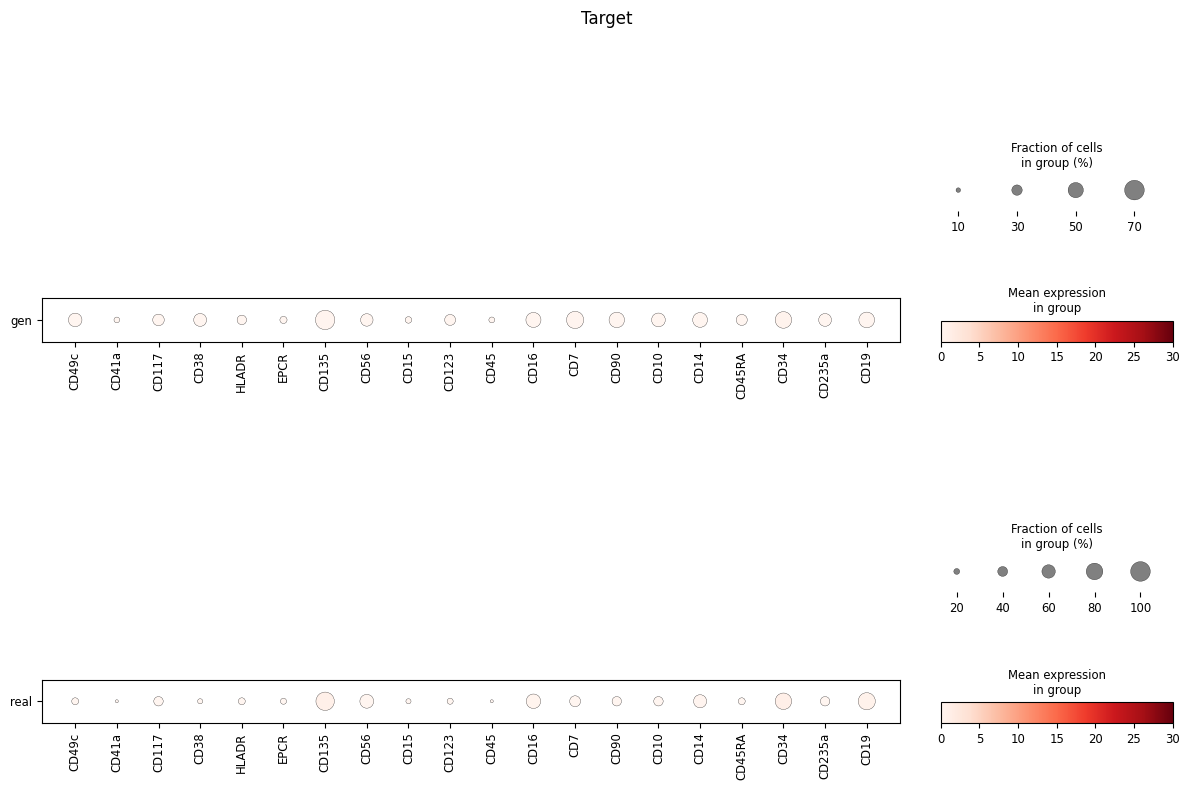

In [23]:
for idx, adata_cond in adatas_dict.items():
    try:
        dotplot(adata_cond, cond=X_conc[idx], vmin=0.0, vmax=30.0)
    except:
        continue

## Check classifier model corresponds to expectations

In [29]:
ct_classifier.target_prediction_model

PerturbationApproximatePosterior(
  (pert_approximate_posterior): ModuleDict(
    (encoder): MLPBlock(
      (net): Sequential(
        (0): Sequential(
          (0): Linear(in_features=26, out_features=256, bias=True)
          (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): ReLU()
          (3): Dropout(p=0.1, inplace=False)
        )
        (1): Sequential(
          (0): Linear(in_features=256, out_features=256, bias=True)
          (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): ReLU()
          (3): Dropout(p=0.1, inplace=False)
        )
        (2): Sequential(
          (0): Linear(in_features=256, out_features=32, bias=True)
          (1): Identity()
        )
      )
    )
    (cell_type): MLPBlock(
      (net): Sequential(
        (0): Sequential(
          (0): Linear(in_features=32, out_features=24, bias=True)
          (1): Identity()
        )
      )
    )
  )
)

## Analyze anndata differences 

In [4]:
new_annot = sc.read_h5ad("/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/data/gdrive/new_dataset/BloodPlus_celltype_pm_500k_.h5ad")

In [5]:
old_annot = sc.read_h5ad("/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/data/gdrive/dataset_unmix8/ds_HID01_logicle_100k_UMAP_ann.h5ad")

In [10]:
new_annot.obs.cell_type.isna().sum()

np.int64(28120)

In [11]:
new_annot_no_nan = new_annot[~new_annot.obs.cell_type.isna()]

In [13]:
np.unique(new_annot_no_nan.obs.cell_type)

array(['CD14Mono', 'CD16Mono', 'CyclingPro1', 'CyclingPro2', 'Early_GMP',
       'EosBasMast1', 'EosBasMast2', 'EosBasMast3', 'EryPro',
       'GMP-Neutro', 'GMP_cycling', 'HSCs', 'LMPP-CLP', 'MLP', 'MPP',
       'MPP_MgkEry', 'MgKEryPro1', 'MgKEryPro2', 'ProB', 'earlyMPP',
       'late_MgkPro', 'preProB', 'pre_cDC1', 'pre_cDC2'], dtype=object)

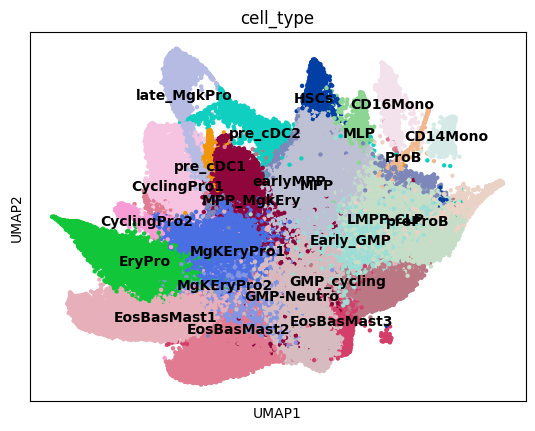

In [16]:
sc.pl.umap(
    new_annot_no_nan,
    color="cell_type",
    legend_loc="on data", 
    s=40
)

In [28]:
# new_annot_no_nan.write_h5ad("/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/data/gdrive/new_dataset/BloodPlus_celltype_pm_500k_filtered_.h5ad")

In [29]:
# new_annot_no_nan.obs.cell_type.isna().sum()

In [30]:
# new_annot_no_nan.obs.cell_type.unique()

In [31]:
# old_annot.obs.cell_type.unique()